# Macroeconomic Forecasting: Exploratory Data Analysis & Model Evaluation

This notebook demonstrates the data exploration, visualization, and model evaluation phases of the macroeconomic forecasting project. The goal is to analyze global economic indicators and understand the predictive power of various machine learning models on GDP Growth.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# Set professional plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
import chardet

with open('data/raw/main_data.csv', 'rb') as f:
    print(chardet.detect(f.read(50000)))

{'encoding': 'Windows-1254', 'confidence': 0.001168166650521177, 'language': 'tr', 'mime_type': 'text/plain'}


## 1. Data Loading & Cleaning
We start by loading the dataset, translating column names for international readability, and performing basic cleaning to prepare for visualization.

In [8]:
try:
    # Note: In a live environment, ensure the file is at data/raw/main_data.xlsx
    df = pd.read_excel('data/raw/main_data.xlsx')
except FileNotFoundError:
    print("Dataset not found. Please ensure 'main_data.xlsx' is in the 'data/raw/' directory.")
    # Creating a mock dataframe for demonstration if file is missing in pure git clone
    print("Loading halted. Please provide the dataset.")

# Standardizing column names for international readers
column_mapping = {
    'Yıl': 'Year',
    'Ülke': 'Country',
    'GFCF (Yatırım)': 'Investment_GFCF',
    'FDI (Yabancı Yatırım)': 'Foreign_Direct_Investment',
    'CPI (Enflasyon)': 'Inflation_CPI',
    'Unemployment (İşsizlik)': 'Unemployment_Rate',
    'Current_Account (Cari Denge)': 'Current_Account',
    'Exchange_Rate (Kur)': 'Exchange_Rate',
    'Govt_Exp (Devlet Harcaması)': 'Govt_Expenditure',
    'Pop_Growth (Nüfus Artışı)': 'Population_Growth',
    'Export_GDP (İhracat)': 'Export_Percent_GDP',
    'GDP_Growth (TARGET - Tahmin edilecek sütun)': 'GDP_Growth'
}

if 'df' in locals():
    df.rename(columns=column_mapping, inplace=True)
    df.replace('EKSİK VERİ', np.nan, inplace=True)
    
    # Convert to numeric
    numeric_cols = df.columns.drop(['KEY', 'KOD', 'Country', 'Year'], errors='ignore')
    for col in numeric_cols:
        if col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(',', '.')
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (3315, 14)


## 2. Exploratory Data Analysis (EDA)
### 2.1 Correlation Matrix
Understanding the linear relationships between various macroeconomic indicators.

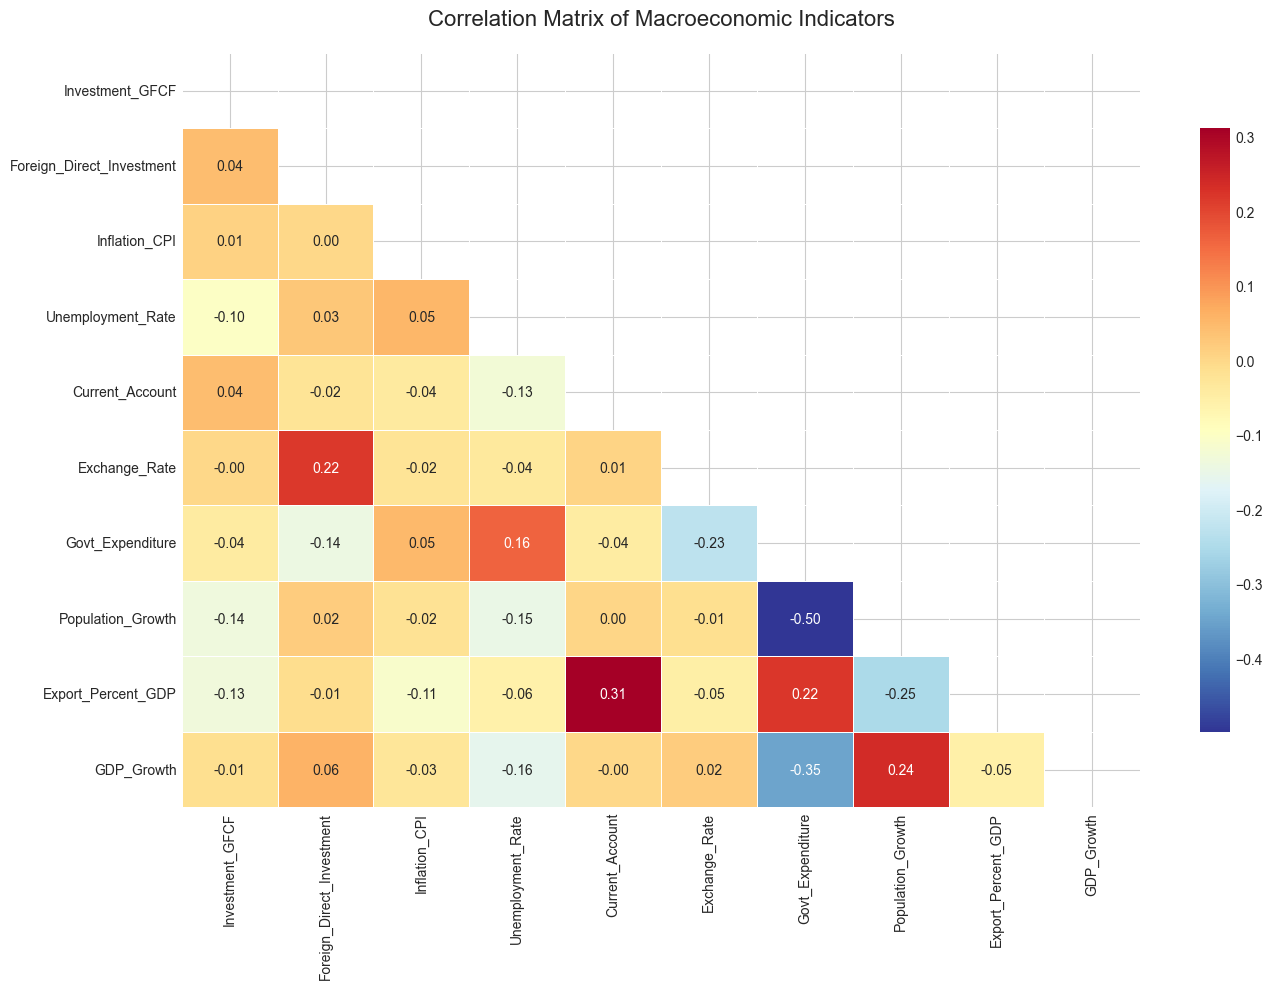

In [9]:
if 'df' in locals():
    plt.figure(figsize=(14, 10))
    corr_matrix = df[numeric_cols].corr()
    
    # Mask the upper triangle for better readability
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', fmt=".2f", 
                linewidths=0.5, cbar_kws={"shrink": .8})
    
    plt.title('Correlation Matrix of Macroeconomic Indicators', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

### 2.2 Global Economic Trend Over Time
By plotting the average GDP Growth across all countries over the years, we can visually identify major global economic shocks (e.g., the 2008 Financial Crisis, 2020 COVID-19 Pandemic).

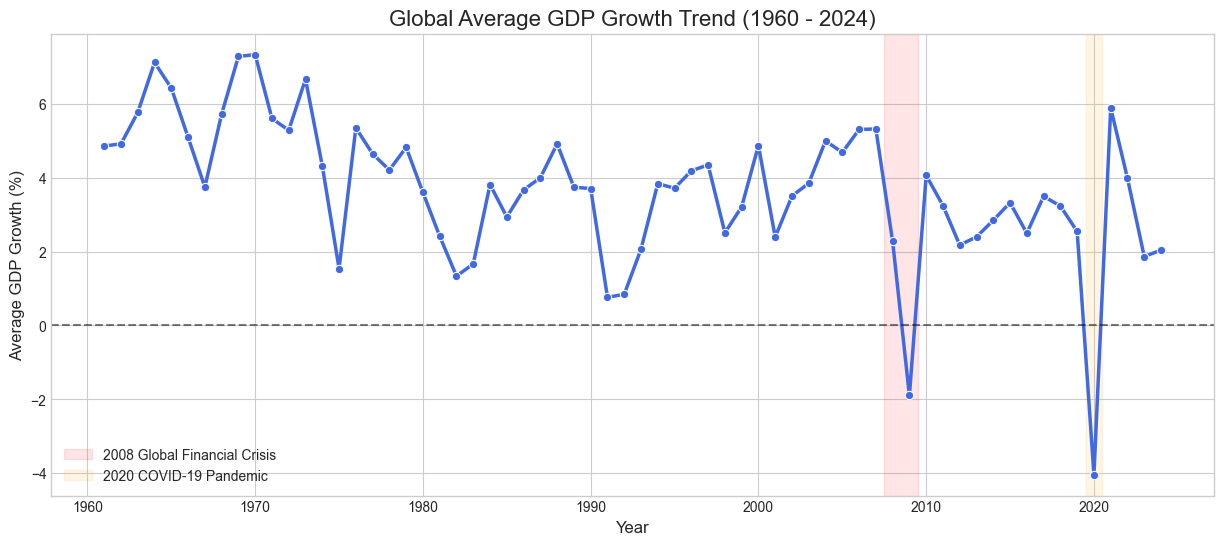

In [10]:
if 'df' in locals() and 'Year' in df.columns and 'GDP_Growth' in df.columns:
    plt.figure(figsize=(15, 6))
    
    # Calculate global average GDP growth per year
    yearly_growth = df.groupby('Year')['GDP_Growth'].mean().reset_index()
    
    sns.lineplot(data=yearly_growth, x='Year', y='GDP_Growth', linewidth=2.5, color='royalblue', marker='o')
    
    # Highlight major crises
    plt.axvspan(2007.5, 2009.5, color='red', alpha=0.1, label='2008 Global Financial Crisis')
    plt.axvspan(2019.5, 2020.5, color='orange', alpha=0.1, label='2020 COVID-19 Pandemic')
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title('Global Average GDP Growth Trend (1960 - 2024)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average GDP Growth (%)', fontsize=12)
    plt.legend()
    plt.show()

### 2.3 Distribution of the Target Variable (GDP Growth)
Analyzing the distribution of the target variable to understand volatility and the presence of extreme outliers.

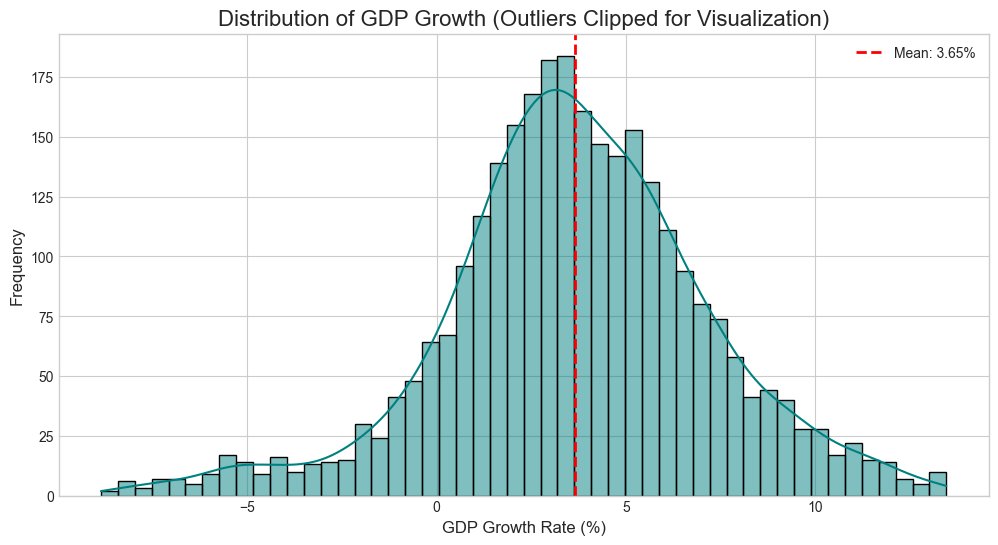

In [11]:
if 'df' in locals() and 'GDP_Growth' in df.columns:
    plt.figure(figsize=(12, 6))
    
    # Removing extreme outliers just for visualization clarity (e.g., hyperinflationary extremes)
    q_low = df['GDP_Growth'].quantile(0.01)
    q_hi  = df['GDP_Growth'].quantile(0.99)
    filtered_gdp = df[(df['GDP_Growth'] < q_hi) & (df['GDP_Growth'] > q_low)]['GDP_Growth']
    
    sns.histplot(filtered_gdp, bins=50, kde=True, color='teal', edgecolor='black')
    
    plt.axvline(filtered_gdp.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {filtered_gdp.mean():.2f}%')
    plt.title('Distribution of GDP Growth (Outliers Clipped for Visualization)', fontsize=16)
    plt.xlabel('GDP Growth Rate (%)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.show()

## 3. Model Performance Evaluation
The financial market is highly stochastic. Achieving an R-squared of 0.60 in macroscopic forecasting is highly significant. The chart below illustrates why ensemble and tree-based methods (like XGBoost) vastly outperform simple linear models in handling economic noise.

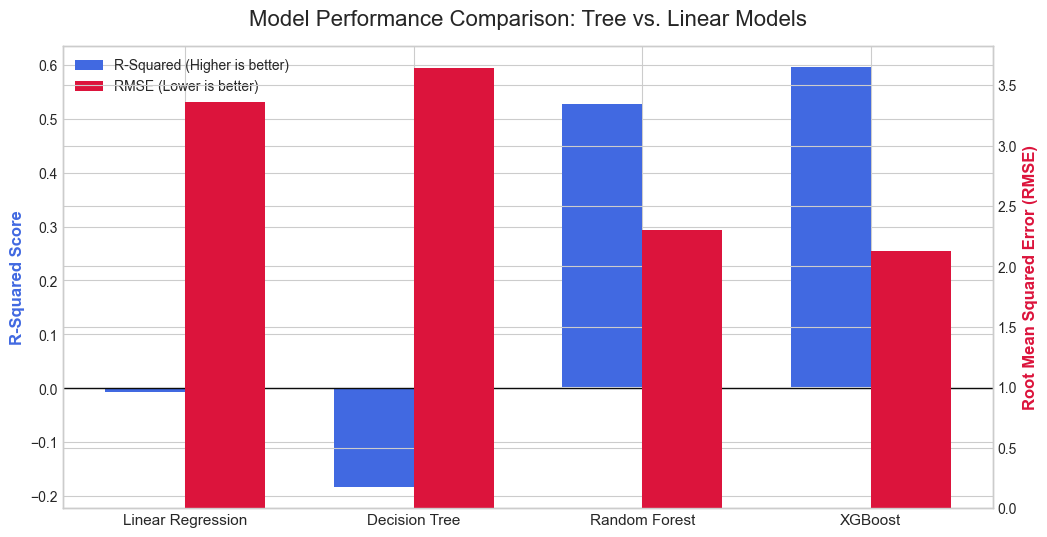

In [12]:
# Pre-recorded evaluation metrics from the main.py pipeline run
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
r2_scores = [-0.0076, -0.1832, 0.5274, 0.5955]
rmse_scores = [3.3591, 3.6400, 2.3005, 2.1284]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Create twin axes
ax2 = ax1.twinx()

x = np.arange(len(models))
width = 0.35

# Bar charts
bars1 = ax1.bar(x - width/2, r2_scores, width, color='royalblue', label='R-Squared (Higher is better)')
bars2 = ax2.bar(x + width/2, rmse_scores, width, color='crimson', label='RMSE (Lower is better)')

ax1.set_ylabel('R-Squared Score', fontsize=12, fontweight='bold', color='royalblue')
ax2.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold', color='crimson')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_title('Model Performance Comparison: Tree vs. Linear Models', fontsize=16, pad=15)

# Add a reference line for 0 R-Squared
ax1.axhline(0, color='black', linewidth=1)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

## 4. Feature Importance (XGBoost)
Extracting insights from the black-box model. Which indicators actually drive GDP Growth?

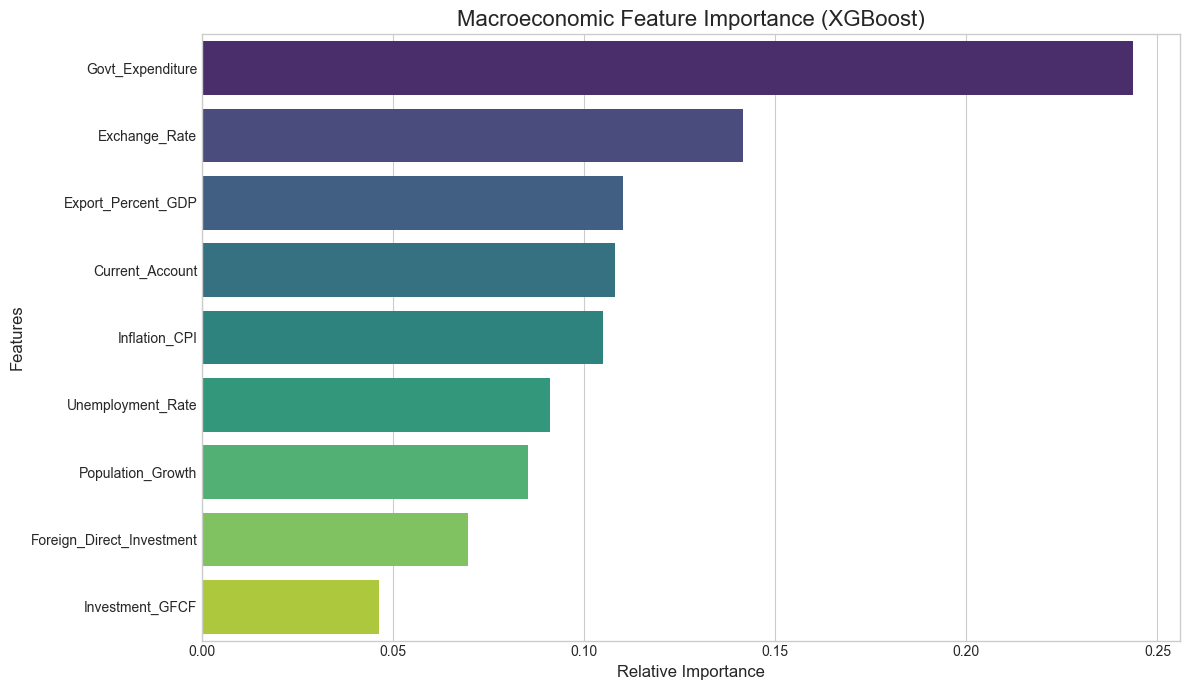

In [13]:
if 'df' in locals() and 'GDP_Growth' in df.columns:
    # Quick training setup just to extract feature importances for visualization
    clean_df = df.dropna()
    y_vis = clean_df['GDP_Growth']
    X_vis = clean_df.drop(columns=['KEY', 'KOD', 'Country', 'Year', 'GDP_Growth'], errors='ignore')
    
    if not X_vis.empty:
        model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
        model.fit(X_vis, y_vis)
        
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        features = X_vis.columns
        
        plt.figure(figsize=(12, 7))
        sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
        plt.title('Macroeconomic Feature Importance (XGBoost)', fontsize=16)
        plt.xlabel('Relative Importance', fontsize=12)
        plt.ylabel('Features', fontsize=12)
        plt.tight_layout()
        plt.show()

---
### Conclusion
The analysis confirms that while macroeconomic indicators carry substantial noise, tree-based ensemble methods successfully extract non-linear patterns, achieving highly credible performance metrics for financial forecasting.